In [1]:
import pathlib
import astropy.units as u
import xarray
import matplotlib.pyplot as plt
import numpy as np
import dask.array
import distributed

from astropy.visualization import ImageNormalize, AsymmetricPercentileInterval, LogStretch

In [2]:
data_dir = pathlib.Path('../data/moxsi_gsfc_calibration_images/')

In [3]:
def fitting_function(X, a, b, c, d, e, f):
    t_det0, t_adc, exposure = X
    return a + b * exposure * np.exp(t_det0 / c) + d * t_det0 + e * t_det0**2 + f * t_adc

# Which images do not have any x-rays on them?

In [4]:
ds = xarray.open_zarr(data_dir / 'images.zarr')

In [5]:
da_coeffs = xarray.open_dataarray(data_dir / 'fit_coefficients.nc')

In [6]:
ds

<xarray.Dataset> Size: 111GB
Dimensions:                 (sample: 4598, row: 2000, column: 1504)
Coordinates:
    exposure_time           (sample) int64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    frame_id                (sample) int64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_adc         (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_detector_0  (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_detector_1  (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_fpga        (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    time                    (sample) datetime64[ns] 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
Dimensions without coordinates: sample, row, column
Data variables:
    data                    (sample, row, column) float64 111GB dask.array<chunksize=(4598, 100, 100), meta=np.ndarray>

In [6]:
ds['data']

<xarray.DataArray 'data' (sample: 4598, row: 2000, column: 1504)> Size: 111GB
dask.array<open_dataset-data, shape=(4598, 2000, 1504), dtype=float64, chunksize=(4598, 100, 100), chunktype=numpy.ndarray>
Coordinates:
    exposure_time           (sample) int64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    frame_id                (sample) int64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_adc         (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_detector_0  (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_detector_1  (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    temperature_fpga        (sample) float64 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
    time                    (sample) datetime64[ns] 37kB dask.array<chunksize=(4598,), meta=np.ndarray>
Dimensions without coordinates: sample, row, column
Attributes:
    unit:     DN

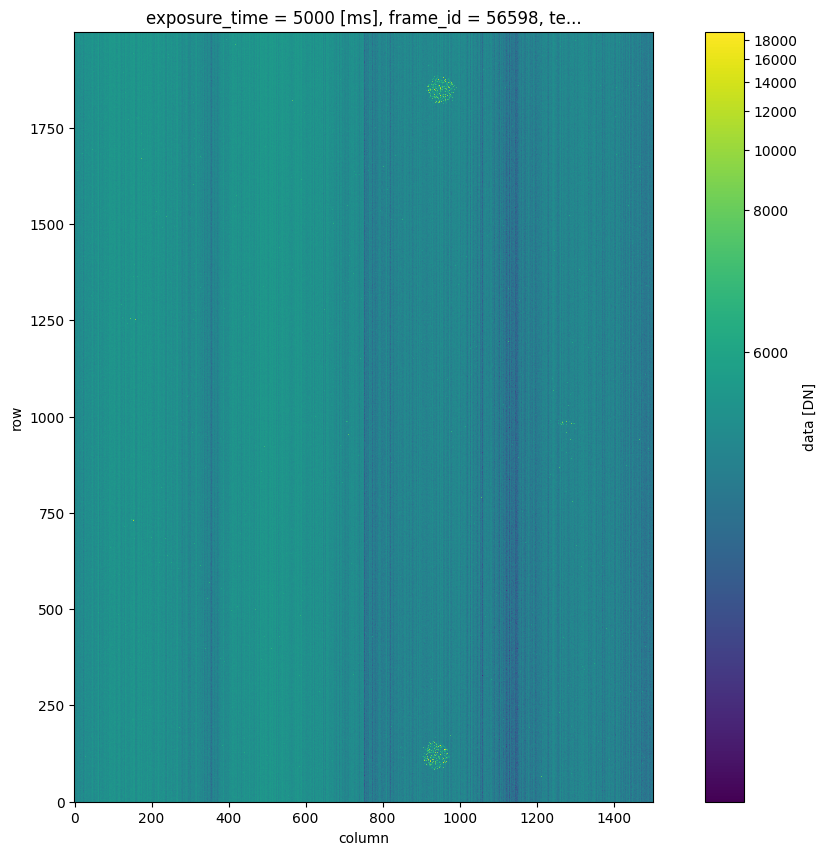

In [7]:
ax = ds['data'][3000,...].plot.imshow(norm=ImageNormalize(stretch=LogStretch()),size=10)
ax.axes.set_aspect('equal')

In [8]:
strip_slice = np.s_[:,250:300,:]

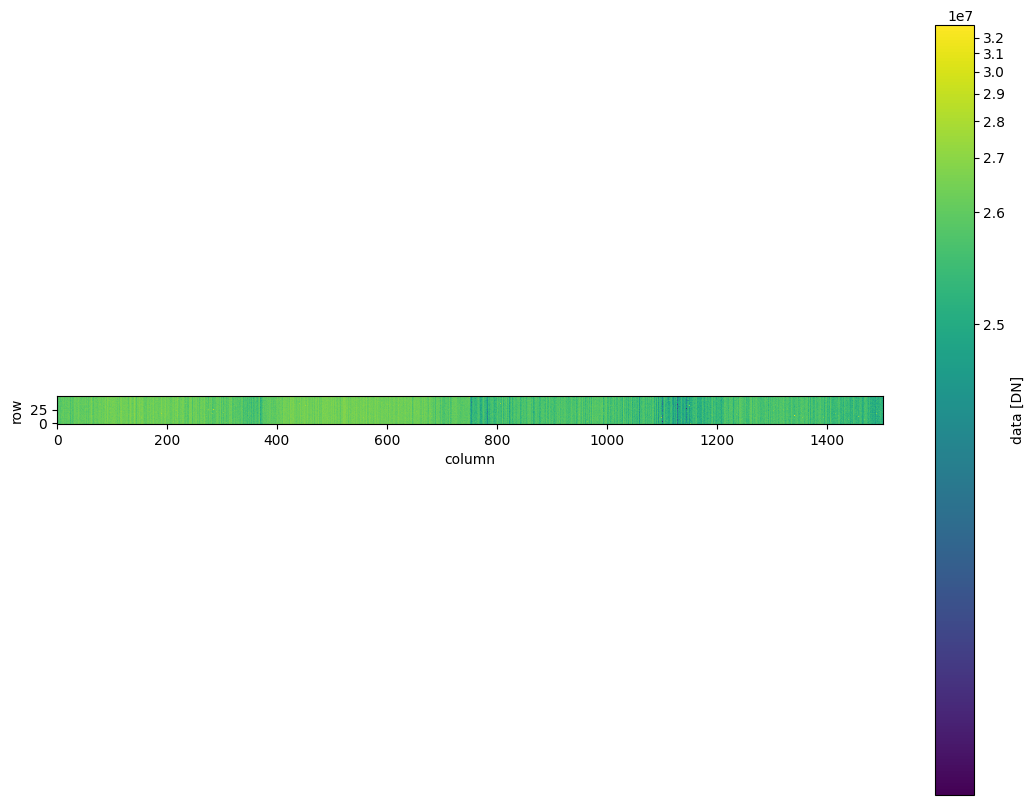

In [9]:
ax = ds['data'][strip_slice].sum(dim='sample').plot.imshow(norm=ImageNormalize(stretch=LogStretch()),size=10)
ax.axes.set_aspect('equal')

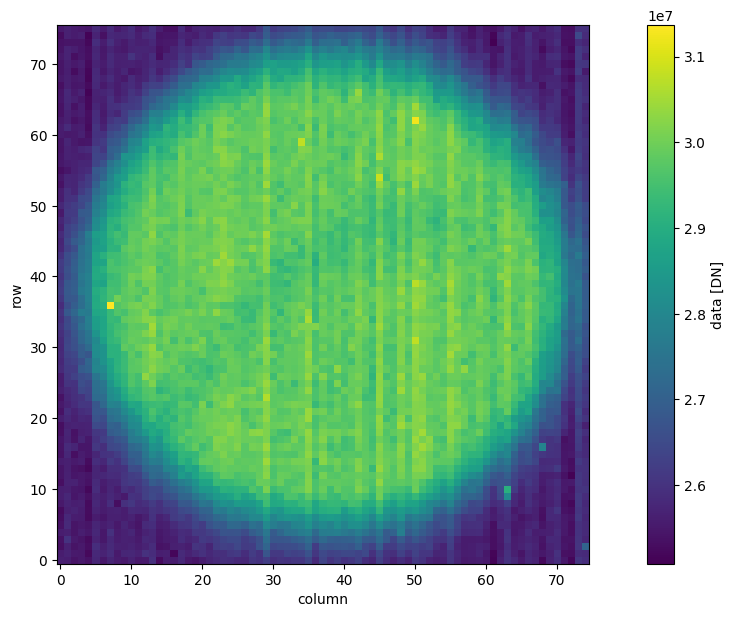

In [9]:
ph1_slice = np.s_[:,82:158,900:975]
ax = ds['data'][ph1_slice].sum(dim='sample').plot.imshow(figsize=(15,7))
ax.axes.set_aspect('equal')

In [7]:
ds_no_pedestal_norm = (ds - da_coeffs.sel(param='a')) / ds.exposure_time

In [13]:
ts_alignment_ph1 = ds['data'][ph1_slice].sum(dim=['row','column']).compute()
#tsap_1250 = ts_alignment_ph1[ds.exposure_time.compute()==1250].compute()
#tsap_2500 = ts_alignment_ph1[ds.exposure_time.compute()==2500].compute()
#tsap_5000 = ts_alignment_ph1[ds.exposure_time.compute()==5000].compute()

(np.float64(20362.614583333332), np.float64(20362.875))

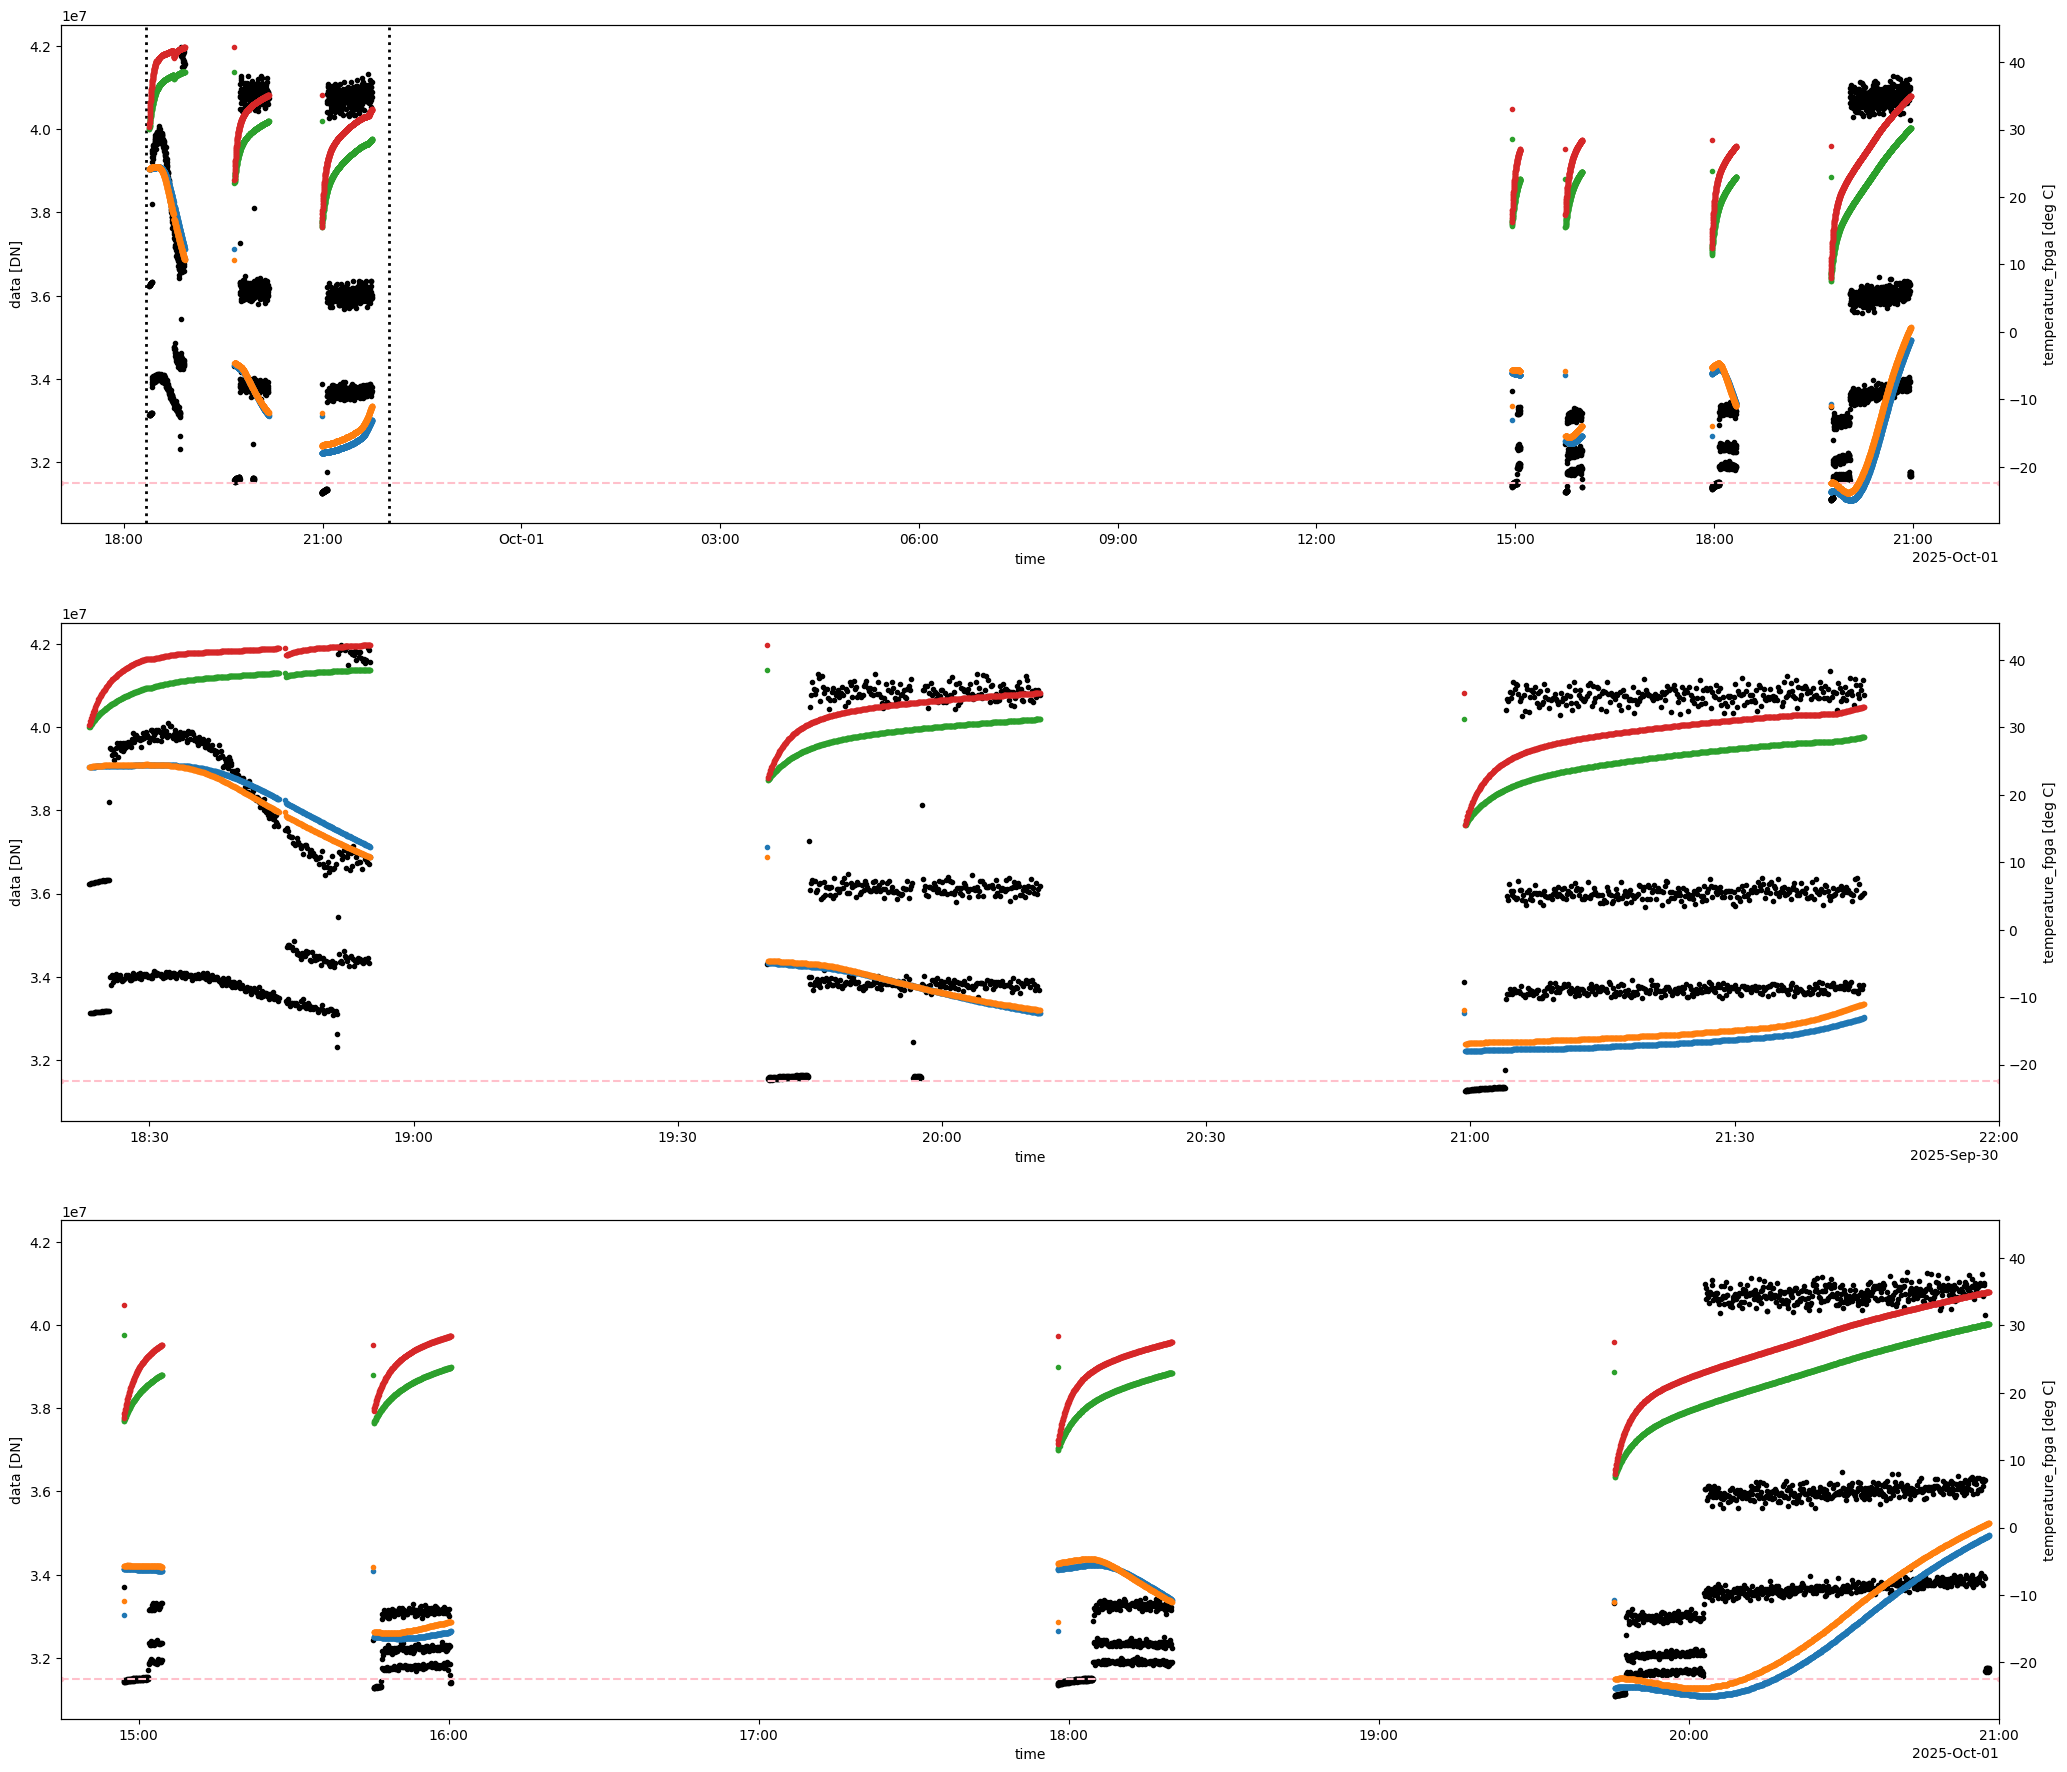

In [15]:
fig = plt.figure(figsize=(25,22))
# Segment 1
ax1 = fig.add_subplot(311)
ts_alignment_ph1.plot(ax=ax1,color='k',x='time', marker='.',ls='')
ax12 = ax1.twinx()
ds.temperature_detector_0.plot(ax=ax12,x='time', marker='.',ls='')
ds.temperature_detector_1.plot(ax=ax12,x='time', marker='.',ls='')
ds.temperature_adc.plot(ax=ax12,x='time', marker='.',ls='')
ds.temperature_fpga.plot(ax=ax12,x='time', marker='.',ls='')
dark_thresh = 3.15e7
ax1.axhline(y=dark_thresh, color='pink', ls='--', marker='.')
# Segment 2
ax2 = fig.add_subplot(312)
ts_alignment_ph1.plot(ax=ax2,color='k',x='time', marker='.', ls='')
#tsap_1250.plot(ax=ax2,color='k',x='time', marker='+', ls='',label='1250')
#tsap_2500.plot(ax=ax2,color='k',x='time', marker='*', ls='',label='2500')
#tsap_5000.plot(ax=ax2,color='k',x='time', marker='o', ls='',label='5000')
ax22 = ax2.twinx()
ds.temperature_detector_0.plot(ax=ax22,x='time', marker='.',ls='')
ds.temperature_detector_1.plot(ax=ax22,x='time', marker='.',ls='')
ds.temperature_adc.plot(ax=ax22,x='time', marker='.',ls='')
ds.temperature_fpga.plot(ax=ax22,x='time', marker='.',ls='')
ax2.axhline(y=dark_thresh, color='pink', ls='--', marker='.')
time_lims = np.array(['2025-09-30T18:20:00','2025-09-30T22:00:00'],dtype='datetime64[ns]')
ax2.set_xlim(time_lims)
for t in time_lims:
    ax1.axvline(x=t, ls=':', lw=2, color='k')
# Segment 3
ax3 = fig.add_subplot(313)
ts_alignment_ph1.plot(ax=ax3,color='k',x='time', marker='.', ls='')
ax32 = ax3.twinx()
ds.temperature_detector_0.plot(ax=ax32,x='time', marker='.',ls='')
ds.temperature_detector_1.plot(ax=ax32,x='time', marker='.',ls='')
ds.temperature_adc.plot(ax=ax32,x='time', marker='.',ls='')
ds.temperature_fpga.plot(ax=ax32,x='time', marker='.',ls='')
ax3.axhline(y=dark_thresh, color='pink', ls='--', marker='.')
time_lims = np.array(['2025-10-01T14:45:00','2025-10-01T21:00:00'],dtype='datetime64[ns]')
ax3.set_xlim(time_lims)

In [16]:
dark_frames = ds.isel(
    sample=np.where(ts_alignment_ph1 < dark_thresh)[0]
)

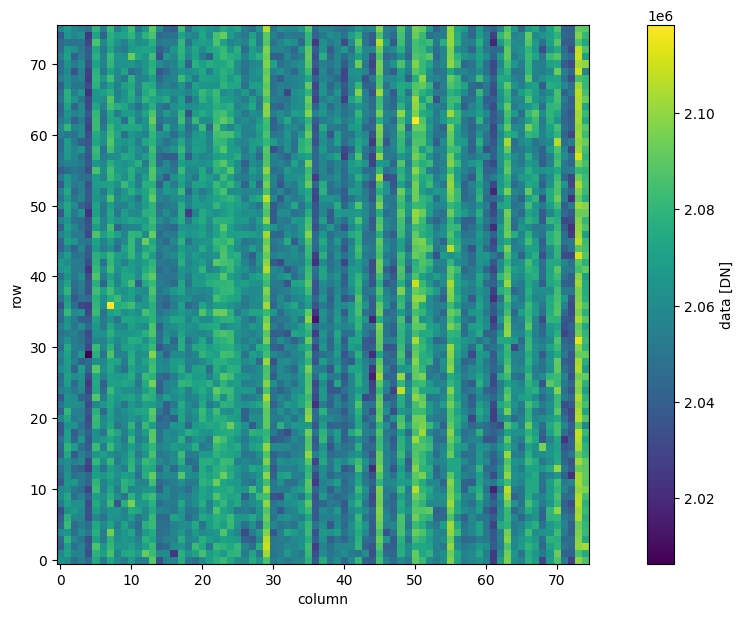

In [17]:
ax = dark_frames['data'][ph1_slice].sum(dim='sample').plot.imshow(figsize=(15,7))
ax.axes.set_aspect('equal')

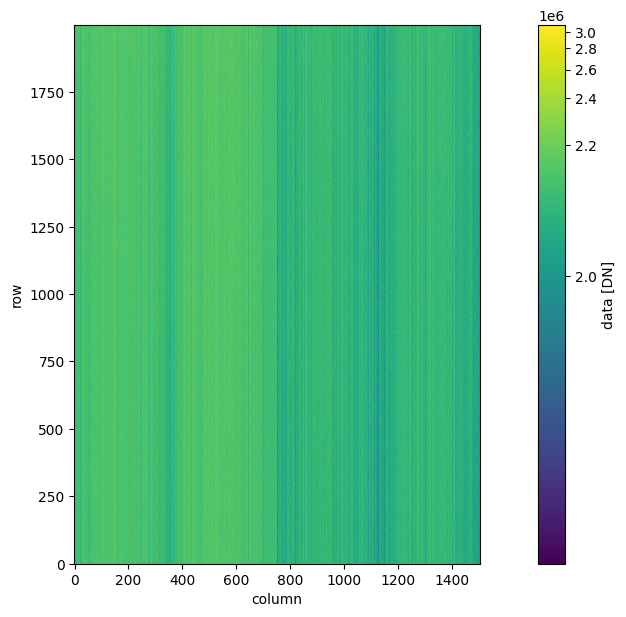

In [19]:
ax = dark_frames['data'].sum(dim='sample').plot.imshow(figsize=(15,7),norm=ImageNormalize(stretch=LogStretch()))
ax.axes.set_aspect('equal')

In [20]:
client = distributed.Client(address='tcp://127.0.0.1:36085')

What if we apply our fitting to only "dark" frames?

In [21]:
da_fit = dark_frames['data'].curvefit(
    (dark_frames.temperature_detector_0, dark_frames.temperature_adc, dark_frames.exposure_time),
    fitting_function,
    reduce_dims=['sample'],
    errors='ignore',
)

In [22]:
da_coeffs_darks = da_fit.curvefit_coefficients.compute()

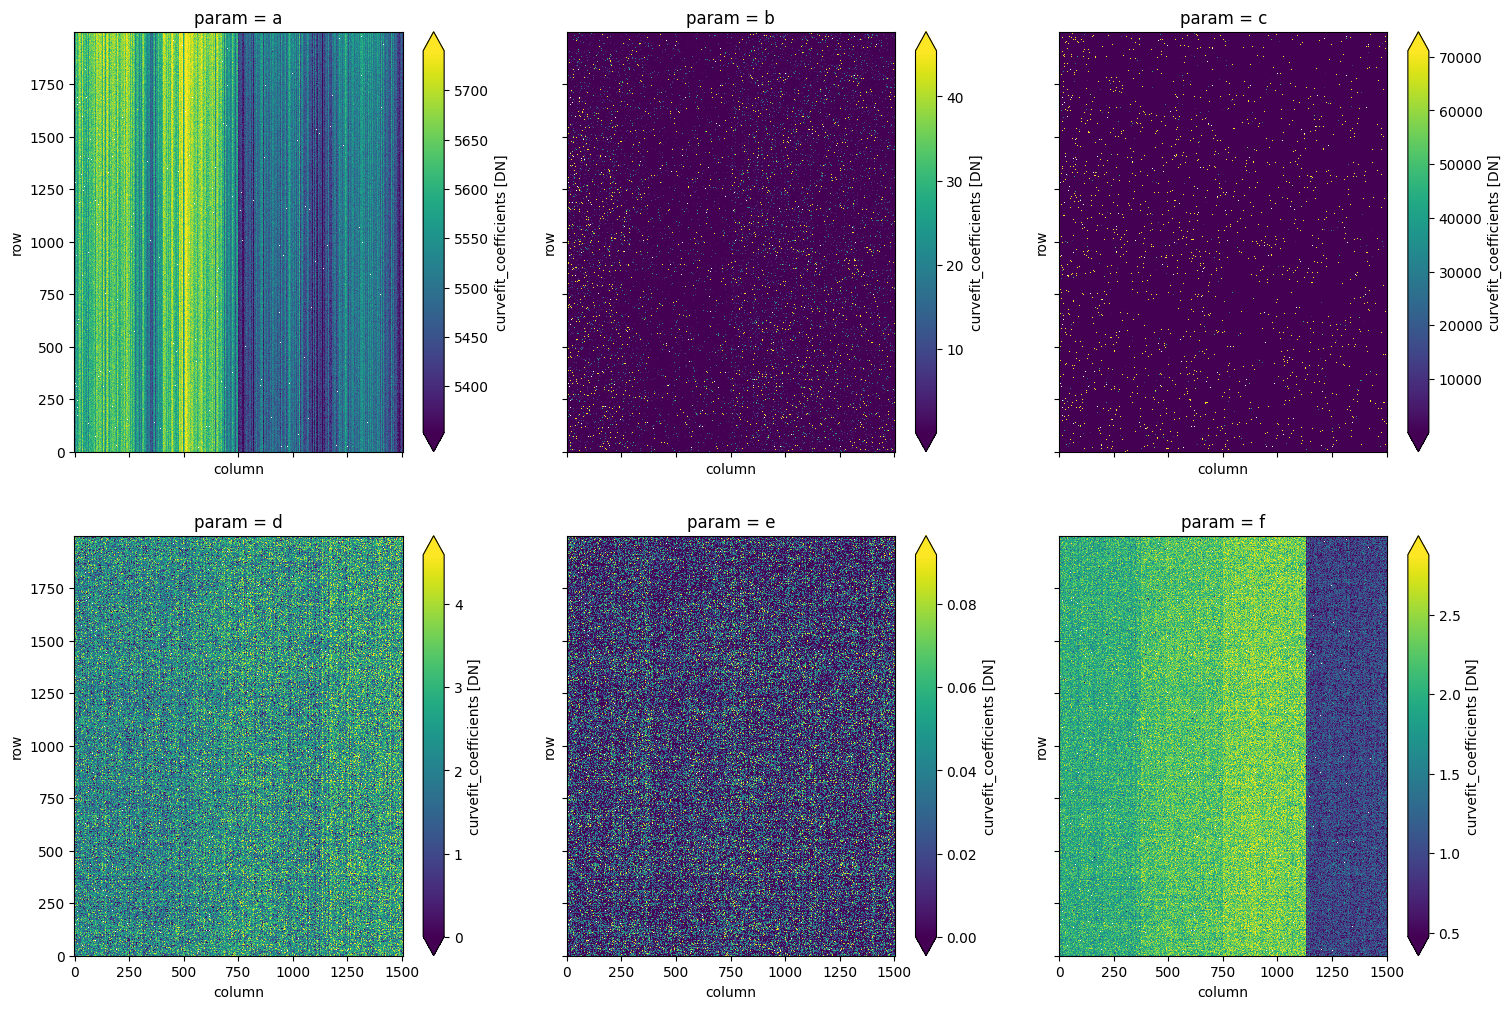

In [33]:
size = 6 
fig,axes = plt.subplots(2,3,figsize=(size*3,size*2),sharex=True,sharey=True)
for i,ax in enumerate(axes.flatten()):
    vmin, vmax = AsymmetricPercentileInterval(1,99).get_limits(da_coeffs_darks[...,i].data)
    da_coeffs_darks[...,i].plot.imshow(ax=ax, vmin=max(0,vmin), vmax=vmax)

What if we drop the dark current terms and fit the dark-only frames again?

In [23]:
def fitting_function_no_exp(X, a, d, e, f):
    t_det0, t_adc, exposure = X
    return a + d * t_det0 + e * t_det0**2 + f * t_adc

In [24]:
da_fit = dark_frames['data'].curvefit(
    (dark_frames.temperature_detector_0, dark_frames.temperature_adc, dark_frames.exposure_time),
    fitting_function_no_exp,
    reduce_dims=['sample'],
    errors='ignore',
)

In [25]:
da_coeffs_darks_no_bc = da_fit.curvefit_coefficients.compute()

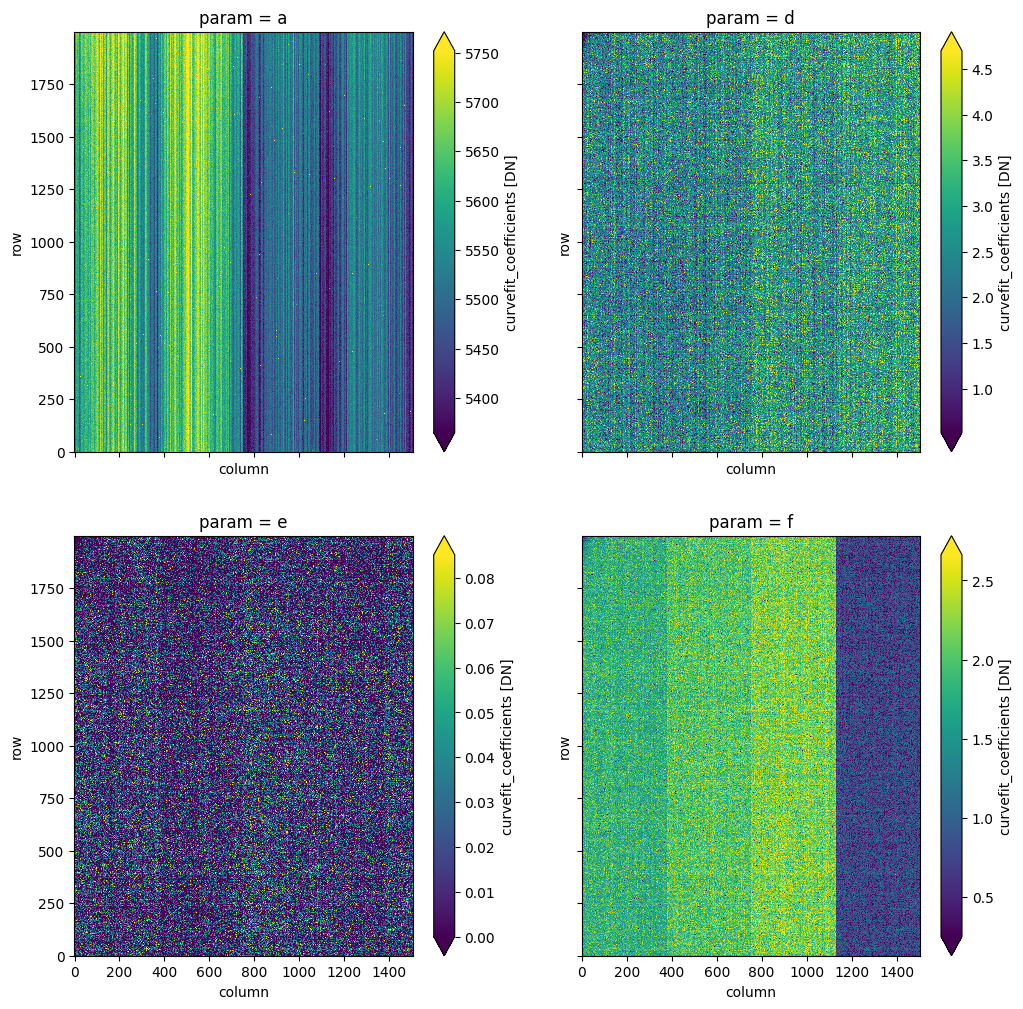

In [57]:
size = 6
fig,axes = plt.subplots(2,2,figsize=(size*2,size*2),sharex=True,sharey=True)
for i,ax in enumerate(axes.flatten()):
    vmin, vmax = AsymmetricPercentileInterval(1,99).get_limits(da_coeffs_darks_no_bc[...,i].data)
    da_coeffs_darks_no_bc[...,i].plot.imshow(ax=ax, vmin=max(0,vmin), vmax=vmax)

Now, compare these two cases with the full fitting procedure

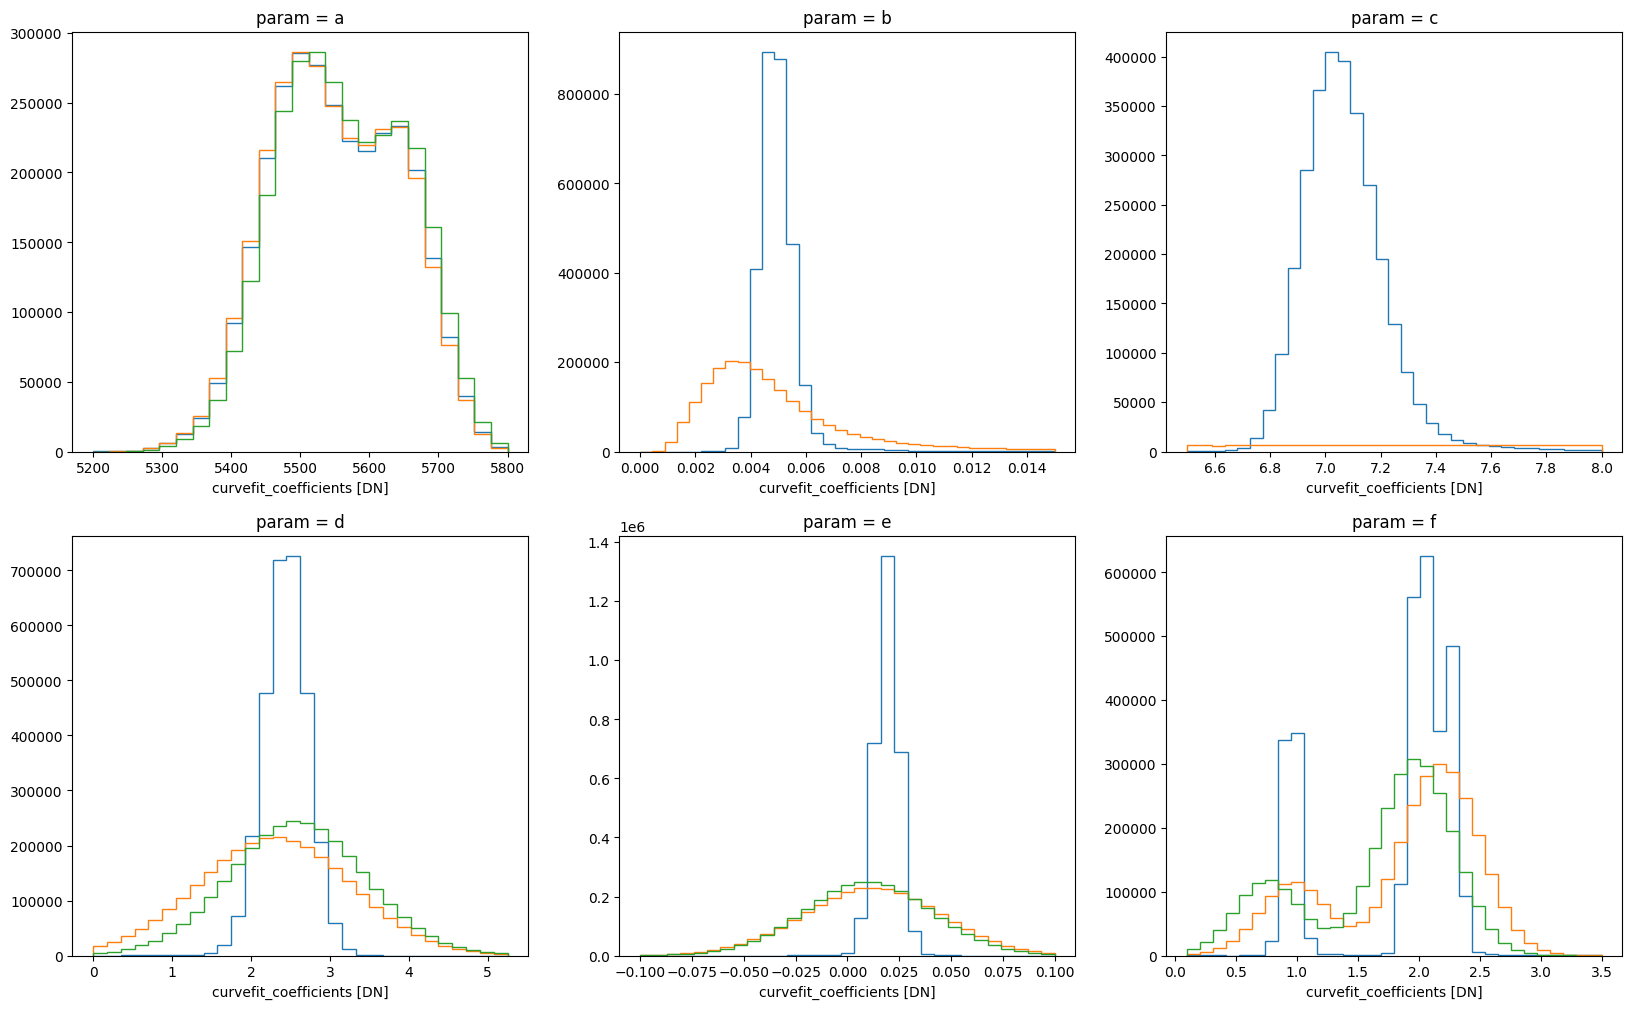

In [26]:
fig,axes = plt.subplots(2,3,figsize=(20,12),sharex=False,sharey=False)
bin_edges = {}
range_dict = {'a': [5200,5800], 'b': [0.0, 0.015], 'c': [6.5,8.0], 'd': [0,5.25], 'e': [-0.1,0.1], 'f': [0.1,3.5]}
for param,ax in zip(da_coeffs.param, axes.flatten()):
    range = range_dict.get(str(param.data))
    _,be,_ = da_coeffs.sel(param=param).plot.hist(ax=ax, bins='doane', range=range, histtype='step', log=False)
    da_coeffs_darks.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step',log=False)
    if param != 'b' and param != 'c':
        da_coeffs_darks_no_bc.sel(param=param).plot.hist(ax=ax, bins=be, histtype='step', log=False)